# Bộ lọc và Làm sạch Dữ liệu Tóm tắt Tiếng Việt (Vietnamese Summarization Cleaning)

Notebook này được thiết kế để chạy trên Kaggle nhằm xử lý và làm sạch bộ dữ liệu tóm tắt văn bản tiếng Việt (~300k dòng), chuẩn bị cho việc huấn luyện mô hình Transformer.

### Các bước xử lý chính:
1. Đọc dữ liệu từ Kaggle Input (`/kaggle/input/...`).
2. Chỉ giữ lại 2 cột quan trọng: `Contents` và `Summary`.
3. Loại bỏ các mẫu bị thiếu giá trị (NaN).
4. Loại bỏ các mẫu trùng lặp và rỗng.
5. Lọc các mẫu theo độ dài phù hợp của nội dung (`Contents` từ 100 đến 1200 từ) hoặc tóm tắt (`Summary` từ 10 đến 150 từ).
6. Trực quan hóa phân phối độ dài dữ liệu bằng biểu đồ `matplotlib`/`seaborn`.
7. Xuất và lưu bộ dữ liệu đã làm sạch dưới dạng CSV để sẵn sàng tải về hoặc huấn luyện tiếp.

In [1]:
!pip install -q sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị và style biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Cấu hình Đường dẫn dữ liệu trên Kaggle
Mặc định bộ dữ liệu khi upload lên Kaggle thường nằm trong thư mục `/kaggle/input/`. Đoạn code sau sẽ quét thư mục đầu vào để tự động phát hiện đường dẫn chính xác của file CSV.

In [3]:
# Liệt kê tất cả các file có sẵn trong đầu vào Kaggle
print("--- Danh sách các file trong thư mục input của Kaggle ---")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Đường dẫn mặc định dự kiến trên Kaggle
INPUT_PATH = "/kaggle/input/datasets/phamtheds/news-dataset-vietnameses/Dataset_articles_NoID.csv"

# Quét tự động nếu đường dẫn mặc định không tồn tại
if not os.path.exists(INPUT_PATH):
    csv_files = []
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if filename.endswith('.csv'):
                csv_files.append(os.path.join(dirname, filename))
    if csv_files:
        INPUT_PATH = csv_files[0]
        print(f"\nTự động tìm thấy file CSV: {INPUT_PATH}")
    else:
        # Đường dẫn chạy ở máy local (relative path)
        INPUT_PATH = "../data/raw/Dataset_articles_NoID.csv/Dataset_articles_NoID.csv"
        print(f"\nKhông chạy trên Kaggle hoặc không tìm thấy file. Dùng đường dẫn mặc định: {INPUT_PATH}")

OUTPUT_PATH = "cleaned_dataset.csv"

--- Danh sách các file trong thư mục input của Kaggle ---
/kaggle/input/datasets/phamtheds/news-dataset-vietnameses/Dataset_articles_NoID.csv


## 2. Tải và Khám phá Dữ liệu Gốc
Đọc dữ liệu bằng Pandas và hiển thị thông tin tổng quan.

In [4]:
print(f"Đang đọc dữ liệu từ: {INPUT_PATH}")
try:
    df = pd.read_csv(INPUT_PATH)
    print(f"Tải thành công! Kích thước ban đầu: {df.shape}")
    display(df.head())
except Exception as e:
    print(f"Lỗi khi đọc file: {e}")
    print("Vui lòng kiểm tra lại đường dẫn INPUT_PATH và cách upload dataset lên Kaggle.")

Đang đọc dữ liệu từ: /kaggle/input/datasets/phamtheds/news-dataset-vietnameses/Dataset_articles_NoID.csv
Tải thành công! Kích thước ban đầu: (313320, 8)


,URL,Title,Summary,Contents,Date,Author(s),Category,Tags
0,https://laodong.vn/bat-dong-san/thong-tin-ngoc...,"Thông tin “Ngọc Trinh mua đất ở Bảo Lộc"" chỉ l...","Lâm Đồng - Lãnh đạo thành phố Bảo Lộc, Lâm Đồn...","Những ngày vừa qua, trên trang Facebook chính ...","Thứ sáu, 20/05/2022 08:56 (GMT+7)",Phương Nhiên,Bất động sản,"['Lâm Đồng', 'Ngọc Trinh', 'Chiêu trò', 'Giá đ..."
1,https://laodong.vn/bat-dong-san/lo-hong-trong-...,Lỗ hổng trong việc thẩm tra năng lực tài chính...,TPHCM - Việc không thể cưỡng chế thuế của hai ...,"Theo thông tin từ Cục Thuế TP.HCM, hiện cơ qua...","Thứ sáu, 20/05/2022 08:10 (GMT+7)",Gia Miêu,Bất động sản,"['Thủ Thiêm', 'Đấu giá đất']"
2,https://laodong.vn/bat-dong-san/som-hoan-thien...,Sớm hoàn thiện các dự án nhà ở xã hội để CNLĐ ...,"Hiện trên địa bàn tỉnh Ninh Bình có 32 khu, cụ...",CNLĐ mong muốn sớm được tiếp cận với nhà ở xã ...,"Thứ sáu, 20/05/2022 07:47 (GMT+7)",NGUYỄN TRƯỜNG,Bất động sản,"['Dự án', 'Nhà ở xã hội', 'Dự án nhà ở xã hội'..."
3,https://laodong.vn/bat-dong-san/chi-tiet-ho-so...,Chi tiết hồ sơ hoàn công nhà ở năm 2022,Hoàn công nhà ở với ý nghĩa là điều kiện để đư...,Hoàn công nhà ở là một thủ tục hành chính tron...,"Thứ sáu, 20/05/2022 06:44 (GMT+7)",Kim Nhung (T/H),Bất động sản,"['Giấy phép xây dựng', 'Hồ sơ hoàn công', 'nhà..."
4,https://laodong.vn/bat-dong-san/khoi-tao-khong...,"Khởi tạo không gian sống đẳng cấp, đón sóng đầ...",Có rất nhiều lý do khiến những dự án thấp nội ...,Đi dọc đường Lê Văn Lương kéo dài xuống khu Dư...,"Thứ năm, 19/05/2022 15:30 (GMT+7)",Huyền Nguyễn,Bất động sản,['An Quý Villa']


## 3. Lọc Cột, Xóa Giá trị Thiếu & Trùng Lặp
Tiến hành tiền xử lý cơ bản để thu được tập dữ liệu sạch, không trùng lặp.

In [5]:
# 1. Chỉ giữ lại 2 cột Contents và Summary
required_cols = ["Contents", "Summary"]
df_filtered = df[required_cols].copy()

# 2. Xóa các mẫu bị NaN
initial_len = len(df_filtered)
df_filtered = df_filtered.dropna(subset=required_cols)
print(f"Đã loại bỏ {initial_len - len(df_filtered)} dòng bị thiếu giá trị (NaN).")
print(f"Kích thước sau khi loại bỏ NaN: {df_filtered.shape}")

# 3. Loại bỏ dòng rỗng hoặc chỉ chứa khoảng trắng
df_filtered["Contents"] = df_filtered["Contents"].astype(str).str.strip()
df_filtered["Summary"] = df_filtered["Summary"].astype(str).str.strip()
df_filtered = df_filtered[(df_filtered["Contents"] != "") & (df_filtered["Summary"] != "")]
print(f"Kích thước sau khi loại bỏ dòng trống: {df_filtered.shape}")

# 4. Loại bỏ các mẫu trùng lặp
pre_dup_len = len(df_filtered)
df_filtered = df_filtered.drop_duplicates(subset=required_cols, keep="first")
print(f"Đã loại bỏ {pre_dup_len - len(df_filtered)} mẫu trùng lặp.")
print(f"Kích thước sau khi loại bỏ trùng lặp: {df_filtered.shape}")

Đã loại bỏ 5722 dòng bị thiếu giá trị (NaN).
Kích thước sau khi loại bỏ NaN: (307598, 2)
Kích thước sau khi loại bỏ dòng trống: (307598, 2)
Đã loại bỏ 22934 mẫu trùng lặp.
Kích thước sau khi loại bỏ trùng lặp: (284664, 2)


In [6]:
print(df_filtered.head())

                                            Contents  \
0  Những ngày vừa qua, trên trang Facebook chính ...   
1  Theo thông tin từ Cục Thuế TP.HCM, hiện cơ qua...   
2  CNLĐ mong muốn sớm được tiếp cận với nhà ở xã ...   
3  Hoàn công nhà ở là một thủ tục hành chính tron...   
4  Đi dọc đường Lê Văn Lương kéo dài xuống khu Dư...   

                                             Summary  
0  Lâm Đồng - Lãnh đạo thành phố Bảo Lộc, Lâm Đồn...  
1  TPHCM - Việc không thể cưỡng chế thuế của hai ...  
2  Hiện trên địa bàn tỉnh Ninh Bình có 32 khu, cụ...  
3  Hoàn công nhà ở với ý nghĩa là điều kiện để đư...  
4  Có rất nhiều lý do khiến những dự án thấp nội ...  


In [7]:
print(df_filtered.iloc[22]["Contents"])

Bộ Xây dựng vừa hướng dẫn Sở Xây dựng tỉnh Bắc Giang về việc bán, cho thuê, cho thuê mua đối với phần 20% diện tích sàn nhà ở thương mại trong công trình nhà ở chung cư xã hội. Theo Bộ Xây dựng, trường hợp phương án quy hoạch chi tiết của dự án xây dựng NƠXH do cơ quan nhà nước có thẩm quyền phê duyệt mà không bố trí quỹ đất riêng để xây dựng công trình kinh doanh thương mại trong phạm vi dự án thì chủ đầu tư được phép dành 20% tổng diện tích sàn nhà ở của dự án đó để bán, cho thuê, thuê mua theo giá kinh doanh thương mại.   Còn theo quy định tại điểm c khoản 1 Điều 6 Thông tư số 20 năm 2016 của Bộ Xây dựng hướng dẫn thực hiện một số nội dung của Nghị định số 100 năm 2015 của Chính phủ về phát triển và quản lý NƠXH.  Đối với phần kinh doanh thương mại trong dự án NƠXH quy định tại điểm b và c khoản 1 Điều 9 Nghị định số 100 thì chủ đầu tư được bán, cho thuê, cho thuê mua theo giá kinh doanh thương mại cho các đối tượng có nhu cầu để bù đắp chi phí đầu tư NƠXH.  Việc này nhằm góp phần g

## 4. Tính toán Độ dài Số từ & Biểu diễn Trực quan
Tính số từ (tương ứng với token/syllable thô trong tiếng Việt khi phân tách bằng khoảng trắng).

Đang tính toán số từ...


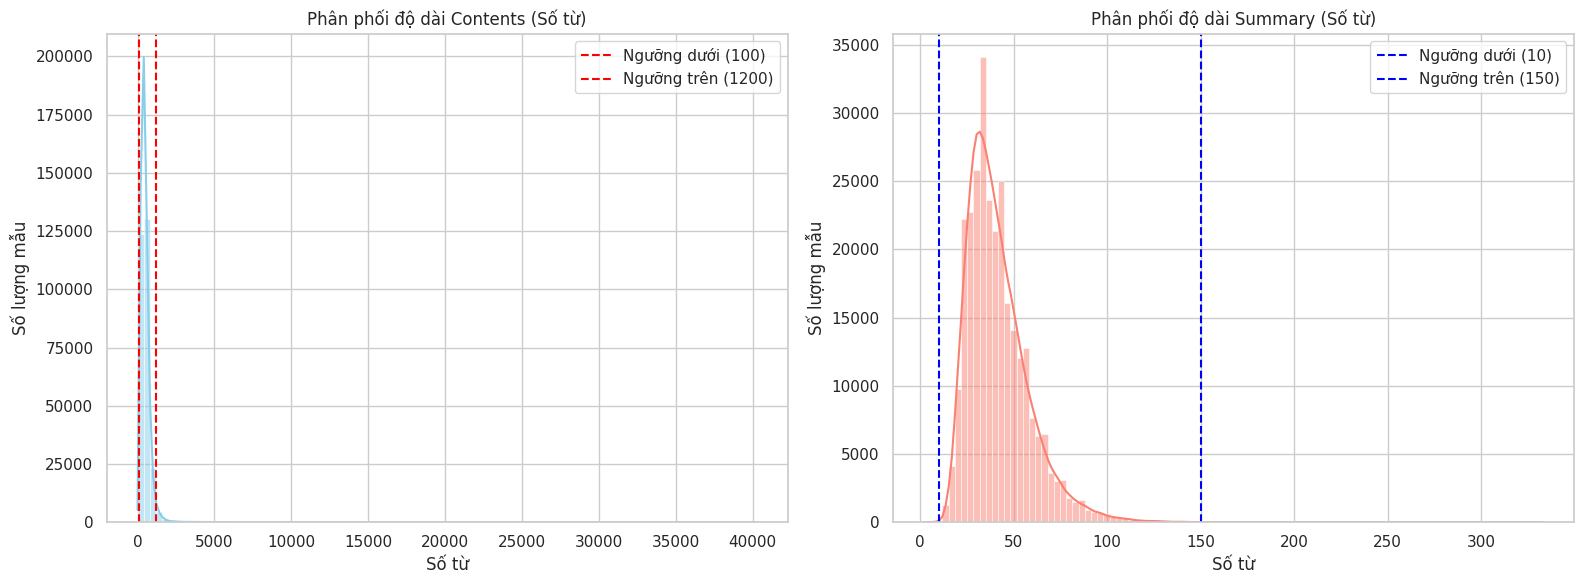

In [8]:
print("Đang tính toán số từ...")
df_filtered["content_len"] = df_filtered["Contents"].apply(lambda x: len(x.split()))
df_filtered["summary_len"] = df_filtered["Summary"].apply(lambda x: len(x.split()))

# Vẽ biểu đồ phân phối độ dài của dữ liệu thô
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_filtered["content_len"], bins=100, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Phân phối độ dài Contents (Số từ)")
axes[0].set_xlabel("Số từ")
axes[0].set_ylabel("Số lượng mẫu")
axes[0].axvline(100, color="red", linestyle="--", label="Ngưỡng dưới (100)")
axes[0].axvline(1200, color="red", linestyle="--", label="Ngưỡng trên (1200)")
axes[0].legend()

sns.histplot(df_filtered["summary_len"], bins=100, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Phân phối độ dài Summary (Số từ)")
axes[1].set_xlabel("Số từ")
axes[1].set_ylabel("Số lượng mẫu")
axes[1].axvline(10, color="blue", linestyle="--", label="Ngưỡng dưới (10)")
axes[1].axvline(150, color="blue", linestyle="--", label="Ngưỡng trên (150)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Lọc theo Điều kiện Độ dài
Chúng ta tiến hành lọc theo đề bài:
- Số từ phần `Contents` từ **100 đến 1200 từ**
- **HOẶC** (`&`) số từ phần `Summary` từ **10 đến 150 từ**.

> **Mẹo**: Trong huấn luyện thực tế, đôi khi việc sử dụng toán tử **VÀ** (`&`) được ưu tiên hơn để đảm bảo cả nội dung đầu vào và tóm tắt đầu ra đều nằm trong ngưỡng tối ưu. Bạn có thể chỉnh sửa toán tử `|` thành `&` dưới đây tùy thuộc vào mục tiêu huấn luyện.

In [9]:
# Tạo mask lọc
content_mask = (df_filtered["content_len"] >= 100) & (df_filtered["content_len"] <= 1200)
summary_mask = (df_filtered["summary_len"] >= 10) & (df_filtered["summary_len"] <= 150)

# Lọc bằng toán tử logic OR (HOẶC)
df_cleaned = df_filtered[content_mask & summary_mask].copy()

print("--- Kết quả sau khi lọc theo độ dài ---")
print(f"Số mẫu ban đầu: {len(df_filtered)}")
print(f"Số mẫu sau khi lọc: {len(df_cleaned)}")
print(f"Đã loại bỏ {len(df_filtered) - len(df_cleaned)} dòng ({((len(df_filtered) - len(df_cleaned))/len(df_filtered))*100:.2f}%)")

--- Kết quả sau khi lọc theo độ dài ---
Số mẫu ban đầu: 284664
Số mẫu sau khi lọc: 273829
Đã loại bỏ 10835 dòng (3.81%)


## 6. Trực quan hóa Dữ liệu đã làm sạch
Hãy xem phân phối độ dài của bộ dữ liệu mới sau khi lọc.

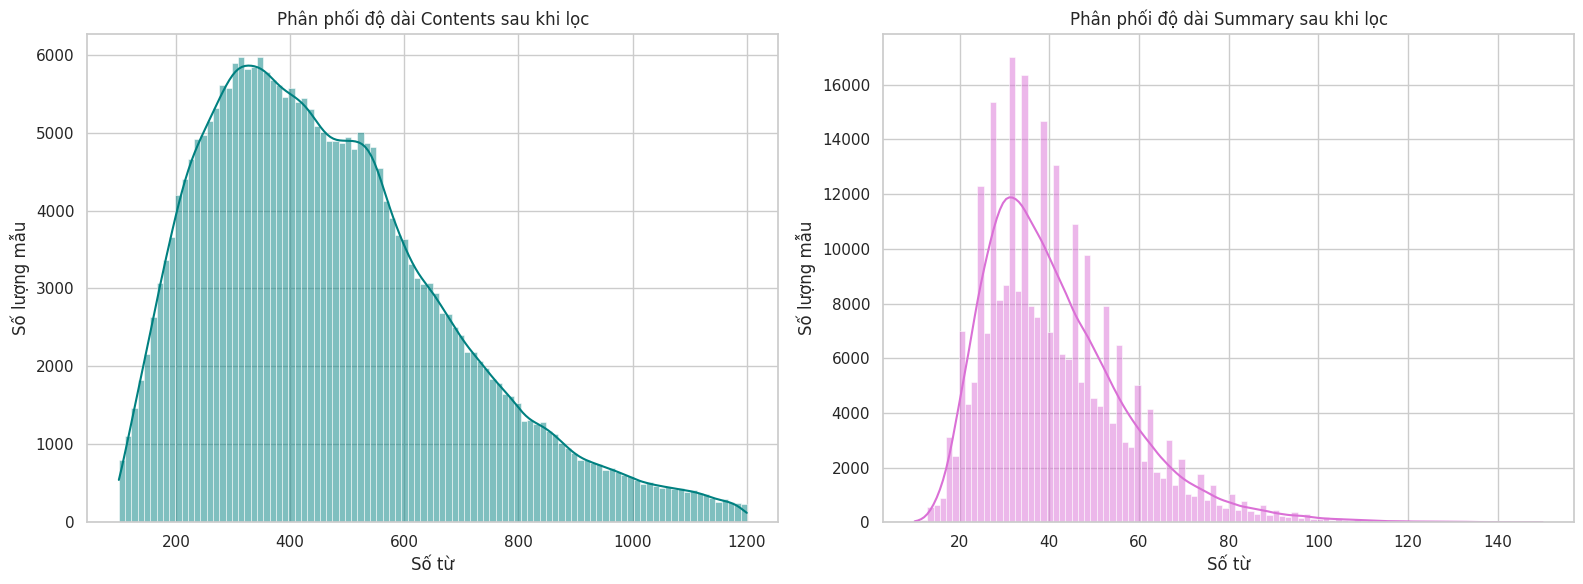

,content_len,summary_len
count,273829.000000,273829.000000
mean,471.505334,41.125231
std,219.095973,15.891440
min,100.000000,10.000000
25%,304.000000,30.000000
50%,437.000000,38.000000
75%,598.000000,49.000000
max,1200.000000,150.000000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_cleaned["content_len"], bins=100, ax=axes[0], color="teal", kde=True)
axes[0].set_title("Phân phối độ dài Contents sau khi lọc")
axes[0].set_xlabel("Số từ")
axes[0].set_ylabel("Số lượng mẫu")

sns.histplot(df_cleaned["summary_len"], bins=100, ax=axes[1], color="orchid", kde=True)
axes[1].set_title("Phân phối độ dài Summary sau khi lọc")
axes[1].set_xlabel("Số từ")
axes[1].set_ylabel("Số lượng mẫu")

plt.tight_layout()
plt.show()

# Hiển thị thống kê chi tiết
display(df_cleaned[["content_len", "summary_len"]].describe())

In [11]:
df_cleaned["compression_ratio"] = df_cleaned["summary_len"] / df_cleaned["content_len"]
print(df_cleaned["compression_ratio"].describe())

count    273829.000000
mean          0.105415
std           0.064267
min           0.010787
25%           0.063228
50%           0.088889
75%           0.128151
max           1.066667
Name: compression_ratio, dtype: float64


In [12]:
df_cleaned = df_cleaned[
    (df_cleaned["compression_ratio"] >= 0.02) &
    (df_cleaned["compression_ratio"] <= 0.50)
].copy()

In [13]:
display(df_cleaned[["content_len", "summary_len", "compression_ratio"]].describe())

,content_len,summary_len,compression_ratio
count,273224.000000,273224.000000,273224.000000
mean,471.593912,41.095859,0.104810
std,218.518902,15.820977,0.061552
min,100.000000,10.000000,0.020000
25%,305.000000,30.000000,0.063253
50%,437.000000,38.000000,0.088838
75%,598.000000,49.000000,0.128000
max,1200.000000,150.000000,0.500000


KIỂM TRA TRÙNG LẶP 1 CỘT (chỉ cần trùng cột contents hoặc summary)

In [14]:
print("Duplicate content:", df_cleaned.duplicated(subset=["Contents"]).sum())
print("Duplicate summary:", df_cleaned.duplicated(subset=["Summary"]).sum())

Duplicate content: 27
Duplicate summary: 420


In [15]:
df_cleaned = df_cleaned.drop_duplicates(subset=["Contents"])
print(len(df_cleaned))
# có 420 bản dữ liệu trùng summary với nhau trong 270k mẫu thì chưa cần xóa
# Ví dụ các bản tin dự báo thời tiết tuy khác nhau nhưng đều có tóm tắt là dự báo thời tiết thì cũng chấp nhận được
# tỉ lệ trùng là 0.015% là nhỏ, không ảnh hưởng nhiều

273197


Đã xuất file ảnh: phan_phoi_du_lieu.png


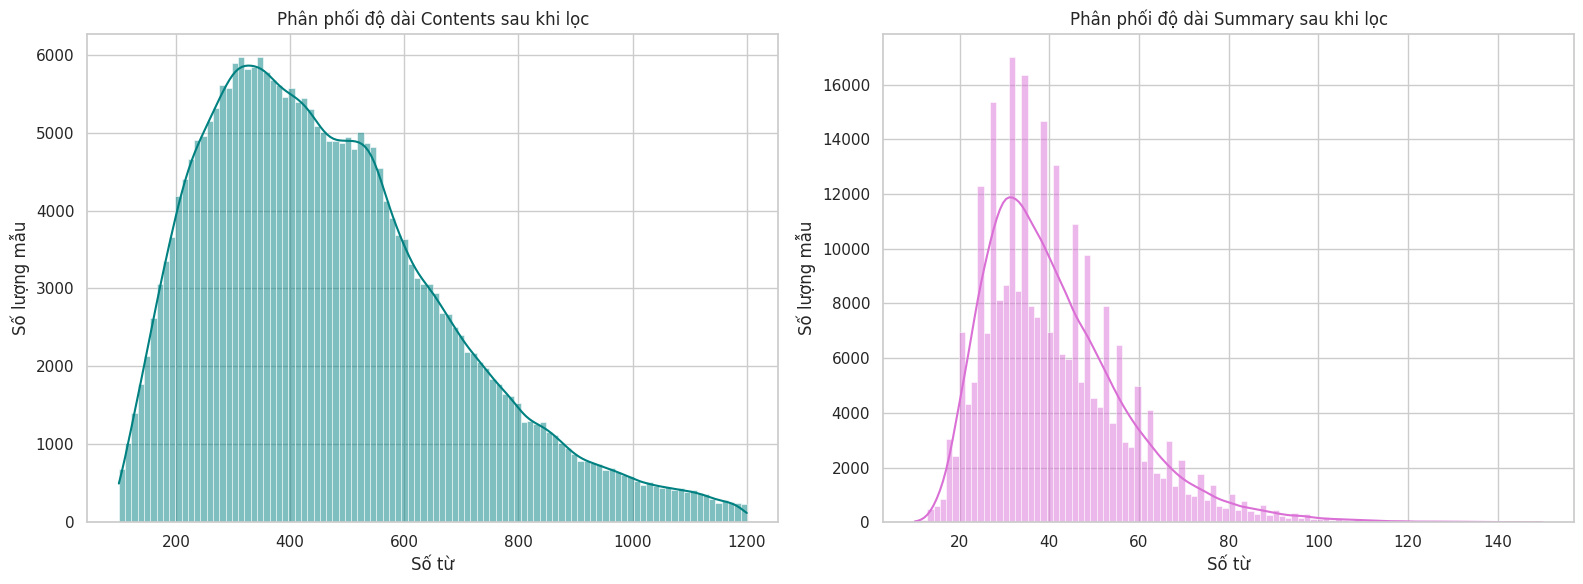

,content_len,summary_len,compression_ratio
count,273197.000000,273197.000000,273197.000000
mean,471.623594,41.096180,0.104795
std,218.506057,15.821491,0.061528
min,100.000000,10.000000,0.020000
25%,305.000000,30.000000,0.063253
50%,437.000000,38.000000,0.088832
75%,598.000000,49.000000,0.127983
max,1200.000000,150.000000,0.500000


Đã xuất file bảng biểu: thong_ke_du_lieu.csv


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_cleaned["content_len"], bins=100, ax=axes[0], color="teal", kde=True)
axes[0].set_title("Phân phối độ dài Contents sau khi lọc")
axes[0].set_xlabel("Số từ")
axes[0].set_ylabel("Số lượng mẫu")

sns.histplot(df_cleaned["summary_len"], bins=100, ax=axes[1], color="orchid", kde=True)
axes[1].set_title("Phân phối độ dài Summary sau khi lọc")
axes[1].set_xlabel("Số từ")
axes[1].set_ylabel("Số lượng mẫu")

plt.tight_layout()

# ==========================================
# 🟢 BỔ SUNG 1: LƯU KHUNG VẼ THÀNH FILE ẢNH
# (Phải gọi lệnh này TRƯỚC plt.show())
# ==========================================
plt.savefig("phan_phoi_du_lieu.png", dpi=300, bbox_inches='tight')
print("Đã xuất file ảnh: phan_phoi_du_lieu.png")

plt.show()

# ==========================================
# 🟢 BỔ SUNG 2: LƯU BẢNG MÔ TẢ THÀNH FILE CSV
# ==========================================
# Tính toán bảng thống kê mô tả
stats_df = df_cleaned[["content_len", "summary_len", "compression_ratio"]].describe()

# Hiển thị trực quan trên giao diện notebook
display(stats_df)

# Lưu bảng thống kê thành file CSV để tải về hoặc dùng cho báo cáo
stats_df.to_csv("thong_ke_du_lieu.csv", encoding="utf-8-sig")
print("Đã xuất file bảng biểu: thong_ke_du_lieu.csv")


In [17]:
import unicodedata
import re

def normalize_text(text):
    if not isinstance(text, str):
        return ""
    # 1. Chuẩn hóa Unicode NFC
    text = unicodedata.normalize('NFC', text)
    # 2. Thay \r\n, \n, \r, \t bằng dấu cách
    text = text.replace('\r\n', ' ').replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')
    # 3. Thay thế URL bằng dấu cách
    text = re.sub(r'http[s]?://\S+|www\.\S+', ' ', text)
    # 4. chuẩn hóa nhièu khoảng trắng thành 1 khoảng trắng
    text = re.sub(r'\s+', ' ', text)
    # 5. Strip đầu/cuối chuỗi
    return text.strip()

print("Đang chuẩn hóa văn bản của bộ dữ liệu sạch (df_cleaned)...")
df_cleaned["Contents"] = df_cleaned["Contents"].apply(normalize_text)
df_cleaned["Summary"] = df_cleaned["Summary"].apply(normalize_text)
print("Chuẩn hóa hoàn tất!")

# Kiểm tra lại thống kê độ dài thực tế sau khi chuẩn hóa khoảng trắng
df_cleaned["content_len"] = df_cleaned["Contents"].apply(lambda x: len(x.split()))
df_cleaned["summary_len"] = df_cleaned["Summary"].apply(lambda x: len(x.split()))
display(df_cleaned[["content_len", "summary_len"]].describe())

Đang chuẩn hóa văn bản của bộ dữ liệu sạch (df_cleaned)...
Chuẩn hóa hoàn tất!


,content_len,summary_len
count,273197.000000,273197.000000
mean,471.607946,41.095964
std,218.503473,15.821367
min,99.000000,10.000000
25%,305.000000,30.000000
50%,437.000000,38.000000
75%,598.000000,49.000000
max,1200.000000,150.000000


## 7. Chuẩn hóa Dữ liệu Văn bản (Text Normalization)
Để mô hình Transformer học một cách ổn định nhất và loại bỏ ký tự điều khiển rác từ crawler, chúng ta thực hiện các bước chuẩn hóa sau:
1. **Chuẩn hóa Unicode NFC**: Đảm bảo tất cả chữ tiếng Việt có dấu dùng chung một định dạng biểu diễn chuẩn.
2. **Xử lý ký tự đặc biệt**: Thay thế các ký tự xuống dòng, tab (`\r\n`, `\n`, `\r`, `\t`) bằng một khoảng trắng.
3. **Thu gọn khoảng trắng**: Đổi chuỗi nhiều khoảng trắng liên tục thành đúng 1 khoảng trắng.
4. **Strip**: Cắt bỏ khoảng trắng dư thừa ở đầu và cuối chuỗi.

In [18]:
for _, row in df_cleaned.sample(10, random_state=42).iterrows():
    print("=" * 100)
    print("CONTENT LEN:", row["content_len"])
    print("SUMMARY LEN:", row["summary_len"])
    print("\nCONTENT:")
    print(row["Contents"][:1500])
    print("\nSUMMARY:")
    print(row["Summary"])

CONTENT LEN: 179
SUMMARY LEN: 89

CONTENT:
Theo đó, kết quả giám định chất lượng cho thấy, hầu hết các chỉ tiêu có giá trị đảm bảo cột A theo QCVN 13-MT:2015/BTNMT của Bộ TNMT - Quy chuẩn kỹ thuật quốc gia về nước thải công nghiệp dệt nhuộm. Tuy nhiên, UBND tỉnh Quảng Trị yêu cầu trước khi xả thải, Cty dệt nhuộm phải hoàn thành việc kết nối hệ thống quan trắc tự động để Sở TNMT giám sát. “Quá trình xả thải chỉ được 300m3 ngày và đêm, xả thử trong 20 ngày để cơ quan chức năng giám sát. Cty đã cam kết về quá trình xả thải này, nếu vi phạm, ảnh hưởng đến môi trường thì chúng tôi sẽ đóng cửa nhà máy” - ông Hà Sỹ Đồng, nói. Trước đó, LĐ đã thông tin việc Cty dệt nhuộm xả thải trái phép ra môi trường và bị cơ quan chức năng lập biên bản vi phạm. Người dân ở địa phương lo ngại việc xả thải nếu không được giám sát chặt chẽ sẽ gây ô nhiễm môi trường.

SUMMARY:
Trước thông tin trên mạng xã hội về việc xả thải thẳng ra môi trường tại một khu công nghiệp ở Quảng Trị, ngày 10.8, ông Hà Sỹ Đồng - Ph

--- PHÁT HIỆN PHẦN CỨNG ---
Số lượng GPU khả dụng: 2
  - GPU 0: Tesla T4
  - GPU 1: Tesla T4

Đang tải mô hình paraphrase-multilingual-mpnet-base-v2 từ HuggingFace...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Tải mô hình thành công!

🚀 Kích hoạt Multi-Process Pool trên 2 GPU song song để tăng tốc gấp đôi!

1. Đang tính toán Vector Embedding cho cột Contents (Nội dung gốc)... (Multi-Process Multi-GPU)


/tmp/ipykernel_23/2336701213.py:26: DeprecationWarning: The `encode_multi_process` method has been deprecated, and its functionality has been integrated into `encode`. You can now call `encode` with the same parameters to achieve multi-process encoding.
  contents_embeddings = model.encode_multi_process(



2. Đang tính toán Vector Embedding cho cột Summary (Tóm tắt)... (Multi-Process Multi-GPU)


/tmp/ipykernel_23/2336701213.py:33: DeprecationWarning: The `encode_multi_process` method has been deprecated, and its functionality has been integrated into `encode`. You can now call `encode` with the same parameters to achieve multi-process encoding.
  summary_embeddings = model.encode_multi_process(



Đã đóng Multi-Process Pool an toàn.

3. Đang tính toán Cosine Similarity hàng dọc (Row-wise)...
Tính toán hoàn tất!


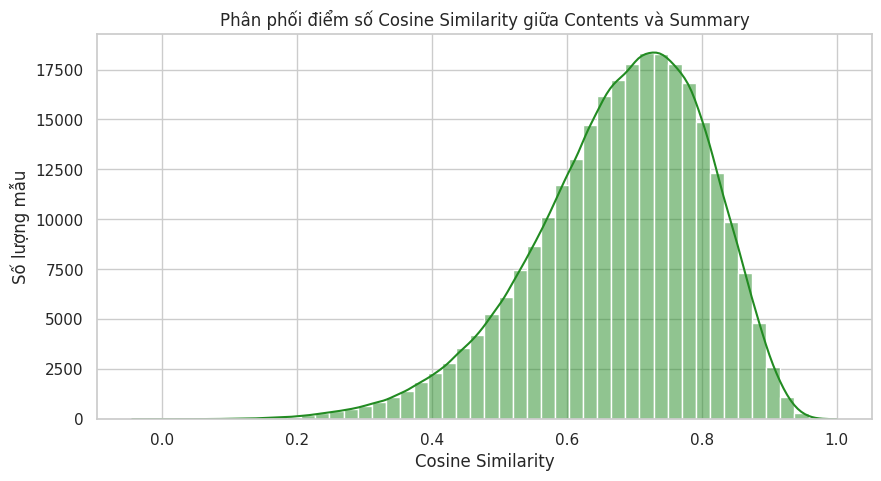

count    273197.000000
mean          0.677949
std           0.128606
min          -0.044348
25%           0.600416
50%           0.693550
75%           0.772483
max           1.000000
Name: cosine_similarity, dtype: float64

In [19]:
# Khởi chạy lệnh sau nếu môi trường Kaggle chưa cài đặt sentence-transformers
# !pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
import torch

# Kiểm tra số lượng GPU khả dụng trên Kaggle
num_gpus = torch.cuda.device_count()
print(f"--- PHÁT HIỆN PHẦN CỨNG ---")
print(f"Số lượng GPU khả dụng: {num_gpus}")
for i in range(num_gpus):
    print(f"  - GPU {i}: {torch.cuda.get_device_name(i)}")

print("\nĐang tải mô hình paraphrase-multilingual-mpnet-base-v2 từ HuggingFace...")
# Khởi tạo mô hình SentenceTransformer cơ bản
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')
print("Tải mô hình thành công!")

# Bắt đầu song song hóa sử dụng Multi-Process Pool (Multi-GPU) nếu có nhiều hơn 1 GPU
if num_gpus > 1:
    print(f"\n🚀 Kích hoạt Multi-Process Pool trên {num_gpus} GPU song song để tăng tốc gấp đôi!")
    # Khởi động pool xử lý song song trên các GPU khả dụng
    gpu_pool = model.start_multi_process_pool()
    
    print("\n1. Đang tính toán Vector Embedding cho cột Contents (Nội dung gốc)... (Multi-Process Multi-GPU)")
    contents_embeddings = model.encode_multi_process(
        df_cleaned["Contents"].tolist(),
        gpu_pool,
        batch_size=64
    )
    
    print("\n2. Đang tính toán Vector Embedding cho cột Summary (Tóm tắt)... (Multi-Process Multi-GPU)")
    summary_embeddings = model.encode_multi_process(
        df_cleaned["Summary"].tolist(),
        gpu_pool,
        batch_size=64
    )
    
    # Dừng pool để giải phóng tài nguyên hệ thống
    model.stop_multi_process_pool(gpu_pool)
    print("\nĐã đóng Multi-Process Pool an toàn.")
else:
    # Chạy đơn GPU hoặc CPU bình thường nếu chỉ có 1 GPU hoặc dùng CPU
    device = "cuda" if num_gpus == 1 else "cpu"
    print(f"\nChạy chế độ đơn thiết bị: {device}")
    model = model.to(device)
    
    print("\n1. Đang tính toán Vector Embedding cho cột Contents (Nội dung gốc)... (Single Device)")
    contents_embeddings = model.encode(
        df_cleaned["Contents"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    
    print("\n2. Đang tính toán Vector Embedding cho cột Summary (Tóm tắt)... (Single Device)")
    summary_embeddings = model.encode(
        df_cleaned["Summary"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True
    )

# 3. Tính toán Cosine Similarity hàng dọc (Row-wise Cosine Similarity) cực kỳ tối ưu RAM
print("\n3. Đang tính toán Cosine Similarity hàng dọc (Row-wise)...")
# Chuẩn hóa vector có độ dài (L2-norm) bằng 1
contents_norms = np.linalg.norm(contents_embeddings, axis=1, keepdims=True)
summary_norms = np.linalg.norm(summary_embeddings, axis=1, keepdims=True)

# Tránh chia cho 0
normalized_contents = contents_embeddings / (contents_norms + 1e-9)
normalized_summaries = summary_embeddings / (summary_norms + 1e-9)

# Phép nhân chập từng hàng (Dot product tương ứng hàng với hàng)
cosine_similarities = np.sum(normalized_contents * normalized_summaries, axis=1)

# Lưu kết quả điểm số vào DataFrame
df_cleaned["cosine_similarity"] = cosine_similarities
print("Tính toán hoàn tất!")

# Trực quan hóa phân phối điểm số tương đồng Cosine
plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned["cosine_similarity"], bins=50, color="forestgreen", kde=True)
plt.title("Phân phối điểm số Cosine Similarity giữa Contents và Summary")
plt.xlabel("Cosine Similarity")
plt.ylabel("Số lượng mẫu")
plt.savefig("phan_phoi_cosine_similarity.png", dpi=300, bbox_inches='tight')
plt.show()

# Hiển thị thống kê chi tiết của độ tương đồng Cosine
display(df_cleaned["cosine_similarity"].describe())

In [20]:
similarity_threshold = 0.5
pre_filter_len = len(df_cleaned)

# Tiến hành lọc dữ liệu
df_cleaned = df_cleaned[df_cleaned["cosine_similarity"] >= similarity_threshold].copy()

print("--- KẾT QUẢ LỌC DỮ LIỆU THEO COSINE SIMILARITY ---")
print(f"Số lượng mẫu trước khi lọc: {pre_filter_len}")
print(f"Số lượng mẫu sau khi lọc (Cosine >= {similarity_threshold}): {len(df_cleaned)}")
print(f"Đã lọc bỏ {pre_filter_len - len(df_cleaned)} mẫu kém chất lượng ({((pre_filter_len - len(df_cleaned))/pre_filter_len)*100:.2f}%)")

--- KẾT QUẢ LỌC DỮ LIỆU THEO COSINE SIMILARITY ---
Số lượng mẫu trước khi lọc: 273197
Số lượng mẫu sau khi lọc (Cosine >= 0.5): 246975
Đã lọc bỏ 26222 mẫu kém chất lượng (9.60%)


Đã xuất file ảnh: phan_phoi_du_lieu.png


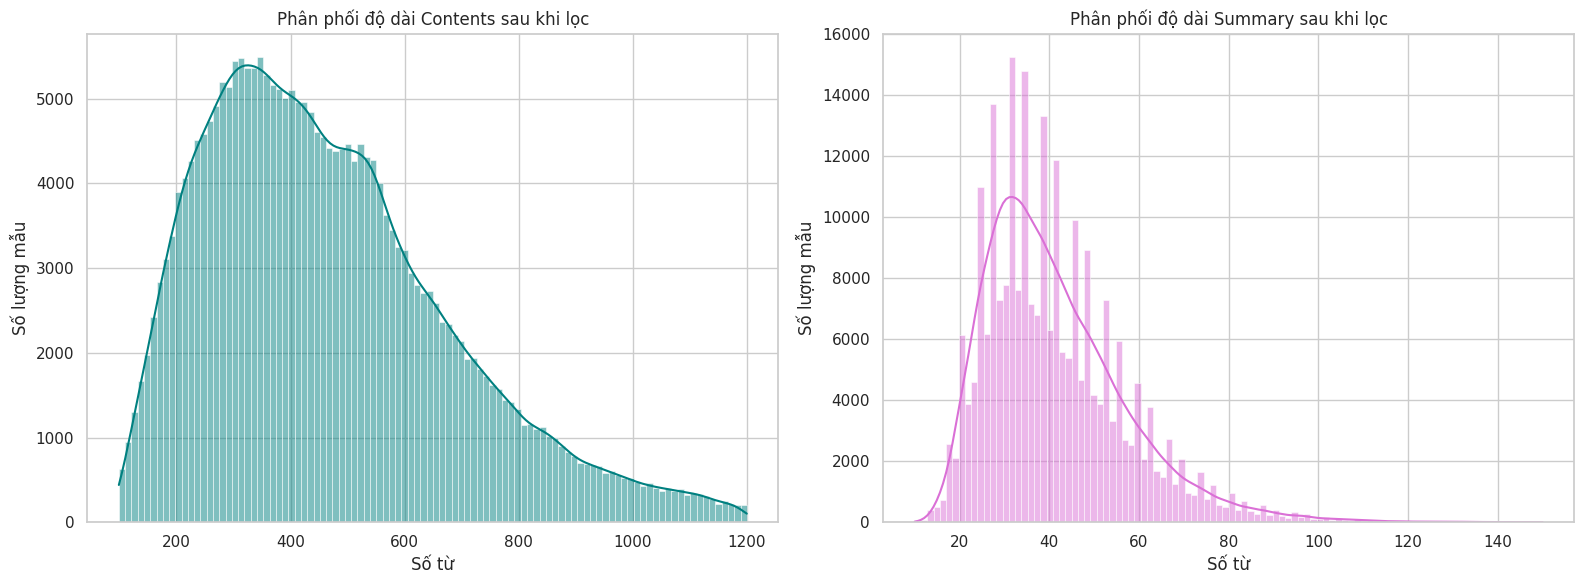

,content_len,summary_len,compression_ratio,cosine_similarity
count,246975.000000,246975.000000,246975.000000,246975.000000
mean,467.639846,41.298038,0.106173,0.705607
std,217.505069,15.849794,0.062010,0.098841
min,99.000000,10.000000,0.020000,0.500001
25%,302.000000,30.000000,0.064236,0.631213
50%,432.000000,38.000000,0.090110,0.708810
75%,593.000000,50.000000,0.129712,0.780561
max,1200.000000,150.000000,0.500000,1.000000


Đã xuất file bảng biểu: thong_ke_du_lieu.csv


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_cleaned["content_len"], bins=100, ax=axes[0], color="teal", kde=True)
axes[0].set_title("Phân phối độ dài Contents sau khi lọc")
axes[0].set_xlabel("Số từ")
axes[0].set_ylabel("Số lượng mẫu")

sns.histplot(df_cleaned["summary_len"], bins=100, ax=axes[1], color="orchid", kde=True)
axes[1].set_title("Phân phối độ dài Summary sau khi lọc")
axes[1].set_xlabel("Số từ")
axes[1].set_ylabel("Số lượng mẫu")



plt.tight_layout()

# ==========================================
# 🟢 BỔ SUNG 1: LƯU KHUNG VẼ THÀNH FILE ẢNH
# (Phải gọi lệnh này TRƯỚC plt.show())
# ==========================================
plt.savefig("phan_phoi_du_lieu.png", dpi=300, bbox_inches='tight')
print("Đã xuất file ảnh: phan_phoi_du_lieu.png")

plt.show()

# ==========================================
# 🟢 BỔ SUNG 2: LƯU BẢNG MÔ TẢ THÀNH FILE CSV
# ==========================================
# Tính toán bảng thống kê mô tả
stats_df = df_cleaned[["content_len", "summary_len", "compression_ratio", "cosine_similarity"]].describe()

# Hiển thị trực quan trên giao diện notebook
display(stats_df)

# Lưu bảng thống kê thành file CSV để tải về hoặc dùng cho báo cáo
stats_df.to_csv("thong_ke_du_lieu.csv", encoding="utf-8-sig")
print("Đã xuất file bảng biểu: thong_ke_du_lieu.csv")


## 8. Phân chia Train/Valid/Test (80/10/10) và Xuất Định dạng JSON Lines (.jsonl)
Chúng ta tiến hành trộn ngẫu nhiên dữ liệu (Shuffle) với seed cố định (`random_state=42`) để đảm bảo tính tái tạo, sau đó phân chia theo tỷ lệ:
- **Train dataset**: 80%
- **Validation dataset**: 10%
- **Test dataset**: 10%

Định dạng xuất ra sẽ là **JSON Lines (.jsonl)**, trong đó mỗi dòng là một đối tượng JSON có cấu trúc chính xác dạng:
`{"Contents": "...", "Summary": "..."}`.

In [22]:
# Chỉ giữ lại đúng 2 cột quan trọng phục vụ huấn luyện
df_final = df_cleaned[required_cols].copy()

# Trộn ngẫu nhiên dữ liệu một cách khách quan để tránh thứ tự tin tức cũ/mới ảnh hưởng chia tập
df_shuffled = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# Tính toán kích thước mẫu của từng tập phân chia
total_samples = len(df_shuffled)
train_size = int(total_samples * 0.8)
val_size = int(total_samples * 0.1)

# Tiến hành cắt tập dữ liệu
df_train = df_shuffled.iloc[:train_size]
df_valid = df_shuffled.iloc[train_size : train_size + val_size]
df_test = df_shuffled.iloc[train_size + val_size :]

print("--- Thống kê kết quả phân chia dữ liệu ---")
print(f"Tổng số mẫu sạch: {total_samples}")
print(f"  - Tập Huấn luyện (Train - 80%): {len(df_train)} mẫu")
print(f"  - Tập Phát triển (Valid - 10%): {len(df_valid)} mẫu")
print(f"  - Tập Đánh giá (Test  - 10%): {len(df_test)} mẫu")

# Lưu dữ liệu dưới định dạng JSON Lines (.jsonl) chất lượng cao
# Thiết lập force_ascii=False để lưu chuẩn các ký tự tiếng Việt Unicode hiển thị trực quan
print("\nĐang xuất dữ liệu ra các file .jsonl...")
df_train.to_json("train.jsonl", orient="records", lines=True, force_ascii=False)
df_valid.to_json("valid.jsonl", orient="records", lines=True, force_ascii=False)
df_test.to_json("test.jsonl", orient="records", lines=True, force_ascii=False)
print("Hoàn thành! Bạn có thể lấy các file 'train.jsonl', 'valid.jsonl', 'test.jsonl' trong thư mục đầu ra của notebook để huấn luyện Transformer.")

--- Thống kê kết quả phân chia dữ liệu ---
Tổng số mẫu sạch: 246975
  - Tập Huấn luyện (Train - 80%): 197580 mẫu
  - Tập Phát triển (Valid - 10%): 24697 mẫu
  - Tập Đánh giá (Test  - 10%): 24698 mẫu

Đang xuất dữ liệu ra các file .jsonl...
Hoàn thành! Bạn có thể lấy các file 'train.jsonl', 'valid.jsonl', 'test.jsonl' trong thư mục đầu ra của notebook để huấn luyện Transformer.
